# Neuron optimization

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jrand
import matplotlib.pyplot as plt
import optax
from tqdm import trange

from eleanor.jax.models import RNN, HeraclesCell, HeraclesParams
from eleanor.jax.variability import StaticWrapper

In [2]:
key = jrand.key(0)
kmodel, kstate, ksim = jrand.split(key, 3)

model = RNN(
    HeraclesCell,
    (1,),
    params=HeraclesParams(threshold=2.5, dt=1e-3),
    param_scale=1e12,
    return_states=True,
    key=kmodel,
)
model

RNN(
  base_model=HeraclesCell(
    shape=(1,),
    params=HeraclesParams(
      A=25.0,
      t_fe=9800.0,
      n_depl=1.4e+16,
      e_off=2e-05,
      d_e=7499.999999999999,
      C_par=0.015,
      C_fe=1.5811049864186066,
      I_dsc=10.0,
      threshold=2.5,
      dt=0.001
    ),
    variability=0.0,
    _eps0=8.854187923944199,
    _q=1.6021766299999998e-07,
    _k=1.3806490000000002e-11,
    _h=6.6260701499999995e-22,
    spike_fn=<function custom_gradient.<locals>.wrapped_fun>,
    param_scale=1000000000000.0,
    n_steps=1000,
    return_states=True,
    A_var=StaticWrapper(
      content=D2DVar(name='A', shape=(1,), variability=0.0, noise=f32[1])
    ),
    n_depl_var=StaticWrapper(
      content=D2DVar(name='n_depl', shape=(1,), variability=0.0, noise=f32[1])
    ),
    P_s_var=StaticWrapper(
      content=D2DVar(name='P_s', shape=(1,), variability=0.0, noise=f32[1])
    ),
    t_fe_var=StaticWrapper(
      content=D2DVar(name='t_fe', shape=(1,), variability=0.0, noise=f3

In [3]:
# input_ = 100 * jnp.concatenate([jnp.ones((300, 1)), jnp.zeros((200, 1))])
# states, outs = model(state, input_, key=jax.random.key(0))
input_ = 100 * jnp.concatenate([jnp.ones((50, 1)), jnp.zeros((50, 1))])
s, v, p = model(input_, key=ksim)

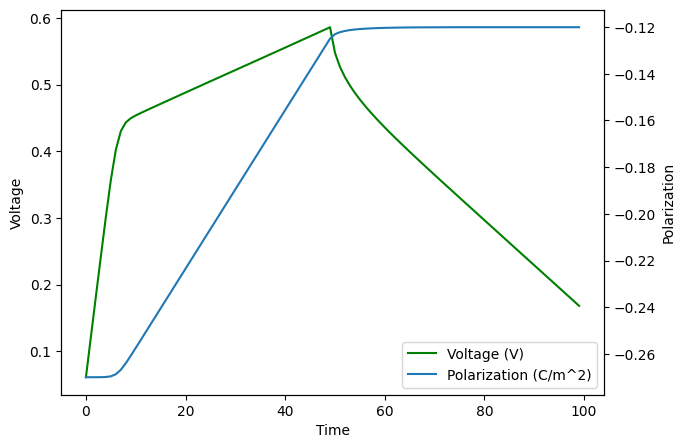

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
default_prop_cycler = plt.rcParams["axes.prop_cycle"]
lns1 = ax.plot(v, "g", label="Voltage (V)")
ax2 = ax.twinx()
lns2 = ax2.plot(p, label="Polarization (C/m^2)")
lns = lns1 + lns2
labs = [label.get_label() for label in lns]
ax.legend(lns, labs, loc=4)
ax.set_xlabel("Time")
ax.set_ylabel("Voltage")
ax2.set_ylabel("Polarization")
plt.show()

In [5]:
key = jax.random.key(0)


class Network(eqx.Module):
    linear: eqx.nn.Linear
    # scaler: eqx.Module
    cell: RNN

    def __init__(self, key):
        k1, k2, k3 = jrand.split(key, 3)
        linearLayer = eqx.nn.Linear(1, 1, use_bias=False, key=key)
        new_weight = jnp.asarray([[0.3]])
        self.linear = eqx.tree_at(lambda x: x.weight, linearLayer, new_weight)
        # self.scaler = Scaler(100, 100)
        self.cell = RNN(
            HeraclesCell,
            (1,),
            params=HeraclesParams(threshold=0.3, dt=1e-3),
            param_scale=1e9,
            return_states=True,
            key=k2,
        )

    def __call__(self, x):
        x = eqx.filter_vmap(self.linear)(x)
        # x = self.scaler(x)
        s, v, p = self.cell(x)
        return s, v, p


model = Network(key)
params, static = eqx.partition(
    model, eqx.is_array, is_leaf=lambda x: isinstance(x, StaticWrapper)
)
outs = model(jnp.zeros((10, 1)))

In [6]:
@eqx.filter_jit
def loss(params, input_, target):
    model = eqx.combine(params, static)
    preds, _, _ = model(input_)
    preds = jnp.sum(preds, axis=0)  # Sum over time
    return jnp.mean((preds - target) ** 2)

In [7]:
opt = optax.adam(learning_rate=5e-3)
opt_state = opt.init(params)

In [8]:
# Input every 5ms
input_ = jnp.array([[0], [0], [0], [0], [0], [0], [0], [0], [0], [1.0]] * 10)
target = jnp.array([3.0])

In [9]:
print("Optimizing")
loss_rec = []
param_rec = []
state = [params, opt_state]
nb_epochs = 50
for _ in trange(nb_epochs):
    grad_params, opt_state = state

    loss_val, grads = eqx.filter_value_and_grad(loss)(grad_params, input_, target)
    updates, opt_state = opt.update(grads, opt_state, grad_params)
    loss_rec.append(loss_val)

    new_param = eqx.apply_updates(grad_params, updates)
    state = [new_param, opt_state]
    param_rec.append(new_param.linear.weight[0, 0])
loss_rec = jnp.stack(loss_rec)
param_rec = jnp.stack(param_rec)

Optimizing


100%|██████████| 50/50 [00:00<00:00, 72.45it/s]


In [10]:
preds_before, V_before, P_before = model(input_)
preds, V, P = eqx.combine(new_param, static)(input_)

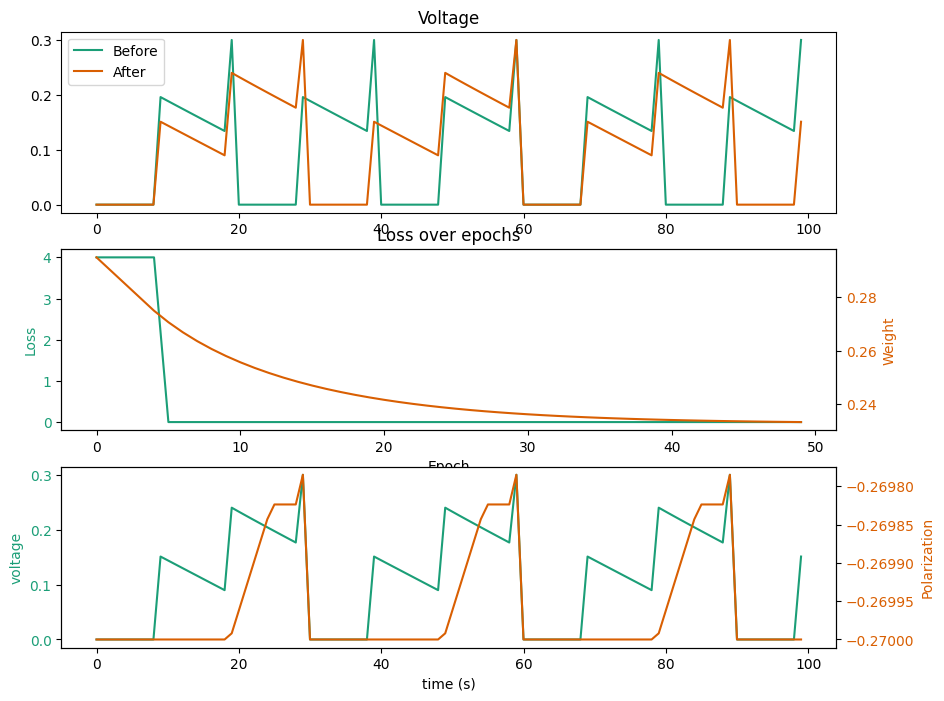

In [11]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# import boilerplot

mpl.rcParams.update(mpl.rcParamsDefault)
# with mpl.style.context("ieeetran"):
plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
plt.title("Voltage")
plt.plot(
    V_before,
    # V_before * C_before + P_before * model.layers[2].A,
    c="#1b9e77",
    label="Before",
)
plt.plot(
    V,
    # V * C_after + P * model.layers[2].A,
    c="#d95f02",
    label="After",
)
plt.legend()

ax1 = plt.subplot(3, 1, 2)
plt.title("Loss over epochs")

color = "#1b9e77"
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color=color)
ax1.plot(loss_rec, color=color)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()

color = "#d95f02"
ax2.set_ylabel("Weight", color=color)
ax2.plot(param_rec, color=color)
ax2.tick_params(axis="y", labelcolor=color)

ax1 = plt.subplot(3, 1, 3)

color = "#1b9e77"
ax1.set_xlabel("time (s)")
ax1.set_ylabel("voltage", color=color)
ax1.plot(V, color=color)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()

color = "#d95f02"
ax2.set_ylabel("Polarization", color=color)
ax2.plot(P, color=color)
ax2.tick_params(axis="y", labelcolor=color)

plt.show()
# plt.savefig("eleanor.svg")